## Part 2 — MapReduce & Visualization

## 0. Setup
Mount Google Drive, install libraries, get the cleaned Parquet file and start Spark.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import glob
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F
from pyspark.sql import types as T
from pyspark import StorageLevel

PROJECT_DIR = "/content/drive/MyDrive/MIT805_Project"
DATA_PATH = f"/content/drive/MyDrive/MIT805_Project/filtered_cleaned_transactions.parquet"

print("Using:", DATA_PATH)

Using: /content/drive/MyDrive/MIT805_Project/filtered_cleaned_transactions.parquet


In [5]:
# Start spark
spark = (
    SparkSession.builder
    .appName("MIT805_AML_Part2")
    .master("local[*]")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

## 1. Load and validate the processing dataset

The cleaned Part 1 Parquet file is loaded directly with Spark.

In [6]:
transactions_raw = spark.read.parquet(DATA_PATH)

# Drop Transfer Type (created in Part 1) so that it can be recreated in Spark showing a mapping example
transactions_raw = transactions_raw.drop("Transfer Type")

transactions_raw.printSchema()
transactions_raw.show(5, truncate=False)

root
 |-- Timestamp: timestamp_ntz (nullable = true)
 |-- From Bank: long (nullable = true)
 |-- From Account: string (nullable = true)
 |-- To Bank: long (nullable = true)
 |-- To Account: string (nullable = true)
 |-- Amount Received: double (nullable = true)
 |-- Receiving Currency: string (nullable = true)
 |-- Amount Paid: double (nullable = true)
 |-- Payment Currency: string (nullable = true)
 |-- Payment Format: string (nullable = true)
 |-- Is Laundering: long (nullable = true)

+-------------------+---------+------------+-------+----------+---------------+------------------+-----------+----------------+--------------+-------------+
|Timestamp          |From Bank|From Account|To Bank|To Account|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+-------------------+---------+------------+-------+----------+---------------+------------------+-----------+----------------+--------------+-------------+
|2022-08-01 00:15:00|20       |80010

In [7]:
# Obtain baseline statistics of the number of transactions, laundered events and high level laundering rate
baseline = (
    transactions_raw
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
)

baseline.show(truncate=False)

baseline_row = baseline.first()
TOTAL_TRANSACTIONS = baseline_row["Transactions"]
TOTAL_LAUNDERING = baseline_row["Laundering"]
BASELINE_RATE = baseline_row["Laundering Rate (%)"]

+------------+----------+--------------------+
|Transactions|Laundering|Laundering Rate (%) |
+------------+----------+--------------------+
|176060109   |96938     |0.055059604671720386|
+------------+----------+--------------------+



## 2. Mapping / transformation

This section is used to show explicit mapping/transformation that was done. These mappings/transformations aid analysis by providing easier ways to group data.

In [8]:
# Recreate the Transfer Type logic from Part 1 but in Spark now.
# Used later for easier aggregation based on the type of transfer
transactions = (
    transactions_raw
    .withColumn(
        "Transfer Type",
        F.when(
            F.col("From Account") == F.col("To Account"),
            F.lit("Self-Transfer")
        )
        .when(
            F.col("From Bank") != F.col("To Bank"),
            F.lit("Cross-Bank Transfer")
        )
        .otherwise(F.lit("Standard Transfer"))
    )
)

transactions.select(
    "Transfer Type"
).show(5, truncate=False)

+-------------+
|Transfer Type|
+-------------+
|Self-Transfer|
|Self-Transfer|
|Self-Transfer|
|Self-Transfer|
|Self-Transfer|
+-------------+
only showing top 5 rows


In [9]:
# Add a boolean field for same currency
# Useful for easier currency aggregations
transactions = (
    transactions
    .withColumn(
        "Same Currency",
        F.col("Payment Currency") == F.col("Receiving Currency")
    )
)

transactions.select(
    "Same Currency"
).show(5, truncate=False)

+-------------+
|Same Currency|
+-------------+
|true         |
|true         |
|true         |
|true         |
|true         |
+-------------+
only showing top 5 rows


In [10]:
# Convert Timestamps into a date
# Used later for daily temporal analysis
transactions = (
    transactions
    .withColumn("Date", F.to_date("Timestamp"))
)

transactions.select(
    "Date"
).show(5, truncate=False)

+----------+
|Date      |
+----------+
|2022-08-01|
|2022-08-01|
|2022-08-01|
|2022-08-01|
|2022-08-01|
+----------+
only showing top 5 rows


## 3. Shuffle / grouping & Reduction / aggregation

This section is used to demonstrate some shuffle/grouping and reduction/aggregation operations done. For meaningful analysis, generally aggregations are performed together with grouping

In [11]:
# Laundering statistics based on payment formatting
payment_format_analysis = (
    transactions
    .groupBy("Payment Format")
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
    .withColumn(
        "Share of Laundering (%)",
        F.col("Laundering") / F.lit(TOTAL_LAUNDERING) * 100
    )
    .withColumn(
        "Relative Risk",
        F.col("Laundering Rate (%)") / F.lit(BASELINE_RATE)
    )
    .orderBy(F.desc("Laundering Rate (%)"))
)

payment_format_analysis.show(truncate=False)

+--------------+------------+----------+--------------------+-----------------------+--------------------+
|Payment Format|Transactions|Laundering|Laundering Rate (%) |Share of Laundering (%)|Relative Risk       |
+--------------+------------+----------+--------------------+-----------------------+--------------------+
|ACH           |21561443    |71367     |0.330993616707379   |73.62128370711176      |6.011550912521958   |
|Bitcoin       |3586541     |1497      |0.041739380645585814|1.5442860384988342     |0.7580762864980016  |
|Cash          |18040752    |3514      |0.019478123750052104|3.624997421032         |0.35376432261338814 |
|Cheque        |69361333    |13003     |0.01874675620781394 |13.41372836245848      |0.34048112621924825 |
|Credit Card   |49911890    |7554      |0.01513467031603091 |7.792609709298727      |0.27487793285599726 |
|Wire          |6339912     |3         |4.731926878480332E-5|0.0030947616001980646  |8.594189708940529E-4|
|Reinvestment  |7258238     |0       

In [12]:
# Use the earlier transformed Date column to create a daily analysis of transactions and laundering
daily_analysis = (
    transactions
    .groupBy("Date")
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
    .orderBy("Date")
)

daily_analysis.show(15, truncate=False)

+----------+------------+----------+--------------------+
|Date      |Transactions|Laundering|Laundering Rate (%) |
+----------+------------+----------+--------------------+
|2022-08-01|4377577     |871       |0.01989685161448902 |
|2022-08-02|1894426     |794       |0.04191243152279371 |
|2022-08-03|1891654     |760       |0.04017648047687368 |
|2022-08-04|1890984     |821       |0.04341654926747133 |
|2022-08-05|2957127     |936       |0.031652343643002144|
|2022-08-06|813053      |641       |0.07883864889496749 |
|2022-08-07|814101      |581       |0.07136706624853673 |
|2022-08-08|1891589     |828       |0.043772722298554285|
|2022-08-09|1890246     |798       |0.042216727346599335|
|2022-08-10|1890146     |791       |0.04184861910138159 |
|2022-08-11|1889965     |847       |0.04481564473416174 |
|2022-08-12|2568299     |888       |0.034575413532458646|
|2022-08-13|814055      |687       |0.08439233221342539 |
|2022-08-14|812267      |670       |0.08248519267679225 |
|2022-08-15|18

In [13]:
# Laundering statistics based on transfer type
transfer_type_analysis = (
    transactions
    .groupBy("Transfer Type")
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
    .withColumn(
        "Share of Laundering (%)",
        F.col("Laundering") / F.lit(TOTAL_LAUNDERING) * 100
    )
    .withColumn(
        "Relative Risk",
        F.col("Laundering Rate (%)") / F.lit(BASELINE_RATE)
    )
    .orderBy(F.desc("Laundering Rate (%)"))
)

transfer_type_analysis.show(truncate=False)

+-------------------+------------+----------+---------------------+-----------------------+-------------------+
|Transfer Type      |Transactions|Laundering|Laundering Rate (%)  |Share of Laundering (%)|Relative Risk      |
+-------------------+------------+----------+---------------------+-----------------------+-------------------+
|Cross-Bank Transfer|164127373   |96190     |0.05860692110145454  |99.22837277435062      |1.0644268416179914 |
|Standard Transfer  |1317582     |713       |0.054114279035384516 |0.7355216736470733     |0.9828308677119615 |
|Self-Transfer      |10615154    |35        |3.2971730791658794E-4|0.036105552002310755   |0.00598837041933824|
+-------------------+------------+----------+---------------------+-----------------------+-------------------+



In [15]:
# Reduce dataset to amount statistics by laundering class
amount_by_class = (
    transactions
    .groupBy("Is Laundering")
    .agg(
        F.count("*").alias("Transactions"),
        F.mean("Amount Paid").alias("Paid Mean"),
        F.expr("percentile_approx(`Amount Paid`, 0.25, 10000)").alias("Paid P25"),
        F.expr("percentile_approx(`Amount Paid`, 0.50, 10000)").alias("Paid Median"),
        F.expr("percentile_approx(`Amount Paid`, 0.75, 10000)").alias("Paid P75"),
        F.expr("percentile_approx(`Amount Paid`, 0.95, 10000)").alias("Paid P95"),
        F.expr("percentile_approx(`Amount Paid`, 0.99, 10000)").alias("Paid P99"),
        F.max("Amount Paid").alias("Paid Max")
    )
    .orderBy("Is Laundering")
)

amount_by_class.show(truncate=False)

+-------------+------------+-------------------+--------+-----------+--------+---------+-------------+-------------------+
|Is Laundering|Transactions|Paid Mean          |Paid P25|Paid Median|Paid P75|Paid P95 |Paid P99     |Paid Max           |
+-------------+------------+-------------------+--------+-----------+--------+---------+-------------+-------------------+
|0            |175963171   |4856770.931723929  |202.55  |1379.39    |10950.55|507043.49|1.051553916E7|4.83458179813635E12|
|1            |96938       |5.602789813089191E7|1318.52 |3749.25    |14325.07|406198.16|1.464593707E7|6.2153998944748E11 |
+-------------+------------+-------------------+--------+-----------+--------+---------+-------------+-------------------+



In [ ]:
# Obtain laundering statistics based on the originating bank
bank_analysis = (
    transactions
    .groupBy("From Bank")
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
    .withColumn(
        "Share of Laundering (%)",
        F.col("Laundering") / F.lit(TOTAL_LAUNDERING) * 100
    )
    .withColumn(
        "Relative Risk",
        F.col("Laundering Rate (%)") / F.lit(BASELINE_RATE)
    )
)

top_laundering_banks = bank_analysis.orderBy(F.desc("Laundering")).limit(15)
top_laundering_banks.show(truncate=False)

+---------+------------+----------+--------------------+-----------------------+-------------------+
|From Bank|Transactions|Laundering|Laundering Rate (%) |Share of Laundering (%)|Relative Risk      |
+---------+------------+----------+--------------------+-----------------------+-------------------+
|70       |16716238    |23647     |0.14146125461960998 |24.39394251996121      |2.5692384727975908 |
|11       |983200      |378       |0.03844589096826688 |0.38993996162495614    |0.6982594807480227 |
|0        |873192      |301       |0.03447122740474031 |0.3105077472198725     |0.6260711025854016 |
|12       |885707      |249       |0.028113134479009427|0.25686521281643937    |0.5105945574187685 |
|20       |878243      |245       |0.02789660720324557 |0.2527388640161753     |0.5066619596993542 |
|3        |539399      |224       |0.04152770027382327 |0.23107553281478885    |0.7542317189057598 |
|27       |721684      |183       |0.02535735862233332 |0.18878045761208195    |0.460543782

In [ ]:
# Obtain behaviours of sender and receiver account pairs
account_pairs = (
    transactions
    .groupBy(
        "From Bank", "From Account", "To Bank", "To Account"
    )
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering Transactions"),
        F.sum("Amount Paid").alias("Total Amount"),
        F.mean("Amount Paid").alias("Mean Amount"),
        F.min("Timestamp").alias("First Transaction"),
        F.max("Timestamp").alias("Last Transaction")
    )
)

account_pairs.show(10, truncate=False)

+---------+------------+-------+----------+------------+-----------------------+-----------------+------------------+-------------------+-------------------+
|From Bank|From Account|To Bank|To Account|Transactions|Laundering Transactions|Total Amount     |Mean Amount       |First Transaction  |Last Transaction   |
+---------+------------+-------+----------+------------+-----------------------+-----------------+------------------+-------------------+-------------------+
|20       |80010E6F0   |27365  |8084250A0 |13          |0                      |799.48           |61.49846153846154 |2022-08-01 00:15:00|2022-10-29 00:10:00|
|544      |8009B23E0   |87354  |82023B780 |2           |0                      |314.8            |157.4             |2022-08-01 00:07:00|2022-09-16 00:26:00|
|1924     |8009B6B00   |1924   |8009B6B00 |4           |0                      |6759.7           |1689.925          |2022-08-01 00:22:00|2022-10-30 01:33:00|
|1601     |800ADCD60   |1601   |800ADCD60 |8        

In [ ]:
# Based on how many transactions a pair has, aggregate that group's laundering patterns
pair_frequency = (
    account_pairs
    .withColumn(
        "Pair Frequency",
        F.when(F.col("Transactions") == 1, "1")
        .when(F.col("Transactions") <= 5, "2-5")
        .when(F.col("Transactions") <= 10, "6-10")
        .when(F.col("Transactions") <= 50, "11-50")
        .when(F.col("Transactions") <= 100, "51-100")
        .otherwise("100+")
    )
    .groupBy("Pair Frequency")
    .agg(
        F.count("*").alias("Account Pairs"),
        F.sum("Transactions").alias("Transactions"),
        F.sum("Laundering Transactions").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
    .withColumn(
        "Share of Laundering (%)",
        F.col("Laundering") / F.lit(TOTAL_LAUNDERING) * 100
    )
)

pair_order = F.when(F.col("Pair Frequency") == "1", 1).when(F.col("Pair Frequency") == "2-5", 2).when(F.col("Pair Frequency") == "6-10", 3).when(F.col("Pair Frequency") == "11-50", 4).when(F.col("Pair Frequency") == "51-100", 5).otherwise(6)

pair_frequency = pair_frequency.orderBy(pair_order)
pair_frequency.show(truncate=False)

+--------------+-------------+------------+----------+--------------------+-----------------------+
|Pair Frequency|Account Pairs|Transactions|Laundering|Laundering Rate (%) |Share of Laundering (%)|
+--------------+-------------+------------+----------+--------------------+-----------------------+
|1             |3675337      |3675337     |26781     |0.7286678745377635  |27.62693680496812      |
|2-5           |2120700      |6759961     |35035     |0.5182722208012739  |36.14165755431307      |
|6-10          |753222       |5925394     |4354      |0.07348034577953803 |4.491530669087458      |
|11-50         |769978       |13939039    |8399      |0.0602552299337135  |8.664300893354515      |
|51-100        |160609       |12622430    |2512      |0.01990108085368665 |2.591347046565846      |
|100+          |694455       |133137948   |19857     |0.014914605714067336|20.48422703171099      |
+--------------+-------------+------------+----------+--------------------+-----------------------+


In [21]:
# Obtain information of reciprocal pairs

# First combine bank and account
from_entity = F.concat_ws(
    "_",
    F.col("From Bank").cast("string"),
    F.col("From Account")
)

to_entity = F.concat_ws(
    "_",
    F.col("To Bank").cast("string"),
    F.col("To Account")
)

# Collapse reciprocal pairs into one pair based on entity A and entity B
pairs = (
    transactions
    .withColumn(
        "Entity A",
        F.when(from_entity <= to_entity, from_entity)
         .otherwise(to_entity)
    )
    .withColumn(
        "Entity B",
        F.when(from_entity <= to_entity, to_entity)
         .otherwise(from_entity)
    )
)

# Get information if a pair involves money flowing in one direction or two
reciprocal_pairs = (
    pairs
    .groupBy("Entity A", "Entity B")
    .agg(
        F.count("*").alias("Transactions"),
        F.sum("Is Laundering").alias("Laundering"),
        F.countDistinct(
            F.concat_ws(
                "_",
                F.col("From Bank").cast("string"),
                F.col("From Account")
            )
        ).alias("Directions")
    )
)

# Analyse unidirectional and bidirectional account-pair transactions for laundering
reciprocal_summary = (
    reciprocal_pairs
    .groupBy("Directions")
    .agg(
        F.count("*").alias("Account Relationships"),
        F.sum("Transactions").alias("Transactions"),
        F.sum("Laundering").alias("Laundering")
    )
    .withColumn(
        "Laundering Rate (%)",
        F.col("Laundering") / F.col("Transactions") * 100
    )
    .withColumn(
        "Share of Laundering (%)",
        F.col("Laundering") / F.lit(TOTAL_LAUNDERING) * 100
    )
    .orderBy("Directions")
)

reciprocal_summary.show(truncate=False)

+----------+---------------------+------------+----------+--------------------+-----------------------+
|Directions|Account Relationships|Transactions|Laundering|Laundering Rate (%) |Share of Laundering (%)|
+----------+---------------------+------------+----------+--------------------+-----------------------+
|1         |7196453              |174281976   |55696     |0.031957406771656066|57.45528069487714      |
|2         |488924               |1778133     |41242     |2.3193990550763077  |42.54471930512286      |
+----------+---------------------+------------+----------+--------------------+-----------------------+



## 8. Explicit RDD Map → Shuffle → Reduce demonstration

The main analysis above uses Spark DataFrames, which Spark optimizes through Catalyst.  
For the rubric, the following two small examples make the MapReduce pattern explicit using RDD operations:

1. `map` transaction → `(key, value)`
2. `reduceByKey` → shuffle records by key and reduce them
3. `collect` only the small aggregated result

These are run on the same processing DataFrame.

### RDD MapReduce example 1 — Payment Format

In [22]:
payment_format_rdd = (
    transactions
    .select("Payment Format", "Is Laundering")
    .rdd
    .map(lambda r: (r["Payment Format"], (1, int(r["Is Laundering"]))))
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
)

print(payment_format_rdd.toDebugString().decode("utf-8"))

payment_format_rdd_result = sorted(
    payment_format_rdd.collect(),
    key=lambda x: x[1][1],
    reverse=True
)

payment_format_rdd_result

(27) PythonRDD[136] at RDD at PythonRDD.scala:57 []
 |   MapPartitionsRDD[135] at mapPartitions at PythonRDD.scala:169 []
 |   ShuffledRDD[134] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(27) PairwiseRDD[133] at reduceByKey at /tmp/ipykernel_4858/2745757245.py:6 []
    |   PythonRDD[132] at reduceByKey at /tmp/ipykernel_4858/2745757245.py:6 []
    |   MapPartitionsRDD[131] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[130] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   SQLExecutionRDD[129] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[128] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[127] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   FileScanRDD[126] at javaToPython at NativeMethodAccessorImpl.java:0 []


[('ACH', (21561443, 71367)),
 ('Cheque', (69361333, 13003)),
 ('Credit Card', (49911890, 7554)),
 ('Cash', (18040752, 3514)),
 ('Bitcoin', (3586541, 1497)),
 ('Wire', (6339912, 3)),
 ('Reinvestment', (7258238, 0))]

### RDD MapReduce example 2 — Transfer Type

In [23]:
transfer_type_rdd = (
    transactions
    .select("Transfer Type", "Is Laundering")
    .rdd
    .map(lambda r: (r["Transfer Type"], (1, int(r["Is Laundering"]))))
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
)

print(transfer_type_rdd.toDebugString().decode("utf-8"))

transfer_type_rdd_result = sorted(
    transfer_type_rdd.collect(),
    key=lambda x: x[1][1],
    reverse=True
)

transfer_type_rdd_result

(27) PythonRDD[147] at RDD at PythonRDD.scala:57 []
 |   MapPartitionsRDD[146] at mapPartitions at PythonRDD.scala:169 []
 |   ShuffledRDD[145] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(27) PairwiseRDD[144] at reduceByKey at /tmp/ipykernel_4858/303727619.py:6 []
    |   PythonRDD[143] at reduceByKey at /tmp/ipykernel_4858/303727619.py:6 []
    |   MapPartitionsRDD[142] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[141] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   SQLExecutionRDD[140] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[139] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[138] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   FileScanRDD[137] at javaToPython at NativeMethodAccessorImpl.java:0 []


[('Cross-Bank Transfer', (164127373, 96190)),
 ('Standard Transfer', (1317582, 713)),
 ('Self-Transfer', (10615154, 35))]

## 9. Spark execution / DAG evidence

The following cells display the physical plans. 

`Exchange` operators around grouped operations — these indicate shuffle boundaries.

### Execution plan 1 — payment format grouping

In [24]:
payment_format_analysis.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (9)
+- Sort (8)
   +- Exchange (7)
      +- Project (6)
         +- Project (5)
            +- HashAggregate (4)
               +- Exchange (3)
                  +- HashAggregate (2)
                     +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [Payment Format#9, Is Laundering#10L]
Batched: true
Location: InMemoryFileIndex [file:/content/drive/MyDrive/MIT805_Project/filtered_cleaned_transactions.parquet]
ReadSchema: struct<Payment Format:string,Is Laundering:bigint>

(2) HashAggregate
Input [2]: [Payment Format#9, Is Laundering#10L]
Keys [1]: [Payment Format#9]
Functions [2]: [partial_count(1), partial_sum(Is Laundering#10L)]
Aggregate Attributes [2]: [count#123L, sum#124L]
Results [3]: [Payment Format#9, count#125L, sum#126L]

(3) Exchange
Input [3]: [Payment Format#9, count#125L, sum#126L]
Arguments: hashpartitioning(Payment Format#9, 32), ENSURE_REQUIREMENTS, [plan_id=1067]

(4) HashAggregate
Input [3]: [Payment Format#9, count#125L,

### Execution plan 2 — account-pair grouping

In [25]:
account_pairs.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (5)
+- HashAggregate (4)
   +- Exchange (3)
      +- HashAggregate (2)
         +- Scan parquet  (1)


(1) Scan parquet 
Output [7]: [Timestamp#0, From Bank#1L, From Account#2, To Bank#3L, To Account#4, Amount Paid#7, Is Laundering#10L]
Batched: true
Location: InMemoryFileIndex [file:/content/drive/MyDrive/MIT805_Project/filtered_cleaned_transactions.parquet]
ReadSchema: struct<Timestamp:timestamp_ntz,From Bank:bigint,From Account:string,To Bank:bigint,To Account:string,Amount Paid:double,Is Laundering:bigint>

(2) HashAggregate
Input [7]: [Timestamp#0, From Bank#1L, From Account#2, To Bank#3L, To Account#4, Amount Paid#7, Is Laundering#10L]
Keys [4]: [From Bank#1L, From Account#2, To Bank#3L, To Account#4]
Functions [6]: [partial_count(1), partial_sum(Is Laundering#10L), partial_sum(Amount Paid#7), partial_avg(Amount Paid#7), partial_min(Timestamp#0), partial_max(Timestamp#0)]
Aggregate Attributes [7]: [count#1857L, sum#1858L, sum#1859, sum#1860, 

### Extended plan — reciprocal relationship analysis

In [26]:
reciprocal_summary.explain(mode="extended")

== Parsed Logical Plan ==
'Sort ['Directions ASC NULLS FIRST], true
+- Project [Directions#1962L, Account Relationships#1982L, Transactions#1983L, Laundering#1984L, Laundering Rate (%)#1993, ((cast(Laundering#1984L as double) / cast(96938 as double)) * cast(100 as double)) AS Share of Laundering (%)#1994]
   +- Project [Directions#1962L, Account Relationships#1982L, Transactions#1983L, Laundering#1984L, ((cast(Laundering#1984L as double) / cast(Transactions#1983L as double)) * cast(100 as double)) AS Laundering Rate (%)#1993]
      +- Aggregate [Directions#1962L], [Directions#1962L, count(1) AS Account Relationships#1982L, sum(Transactions#1960L) AS Transactions#1983L, sum(Laundering#1961L) AS Laundering#1984L]
         +- Aggregate [Entity A#1958, Entity B#1959], [Entity A#1958, Entity B#1959, count(1) AS Transactions#1960L, sum(Is Laundering#10L) AS Laundering#1961L, count(distinct concat_ws(_, cast(From Bank#1L as string), From Account#2)) AS Directions#1962L]
            +- Project

## 10. Visualisation

Spark performs the heavy aggregation first. Only the resulting small tables are converted to Pandas for plotting.

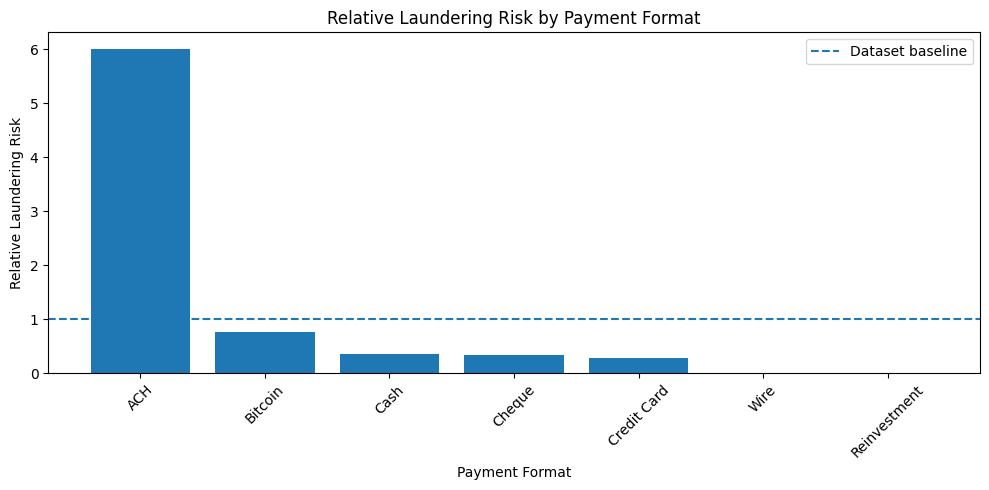

In [27]:
# Plot the elative laundering risk by payment format
payment_plot = payment_format_analysis.select(
    "Payment Format", "Relative Risk"
).toPandas()

plt.figure(figsize=(10, 5))
plt.bar(payment_plot["Payment Format"], payment_plot["Relative Risk"])
plt.axhline(1, linestyle="--", label="Dataset baseline")
plt.xlabel("Payment Format")
plt.ylabel("Relative Laundering Risk")
plt.title("Relative Laundering Risk by Payment Format")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

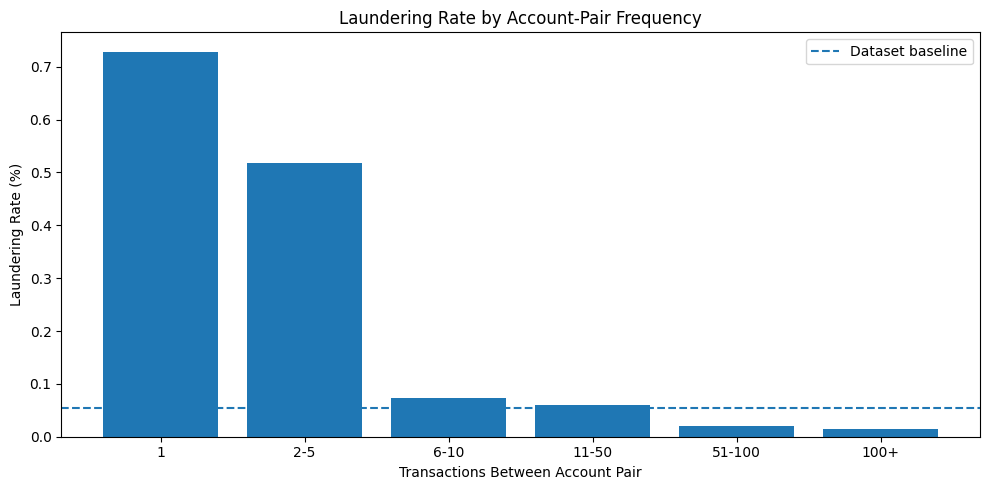

In [28]:
# Plot the laundering rate by account-pair frequency
pair_plot = pair_frequency.select(
    "Pair Frequency", "Laundering Rate (%)"
).toPandas()

plt.figure(figsize=(10, 5))
plt.bar(pair_plot["Pair Frequency"], pair_plot["Laundering Rate (%)"])
plt.axhline(BASELINE_RATE, linestyle="--", label="Dataset baseline")
plt.xlabel("Transactions Between Account Pair")
plt.ylabel("Laundering Rate (%)")
plt.title("Laundering Rate by Account-Pair Frequency")
plt.legend()
plt.tight_layout()
plt.show()

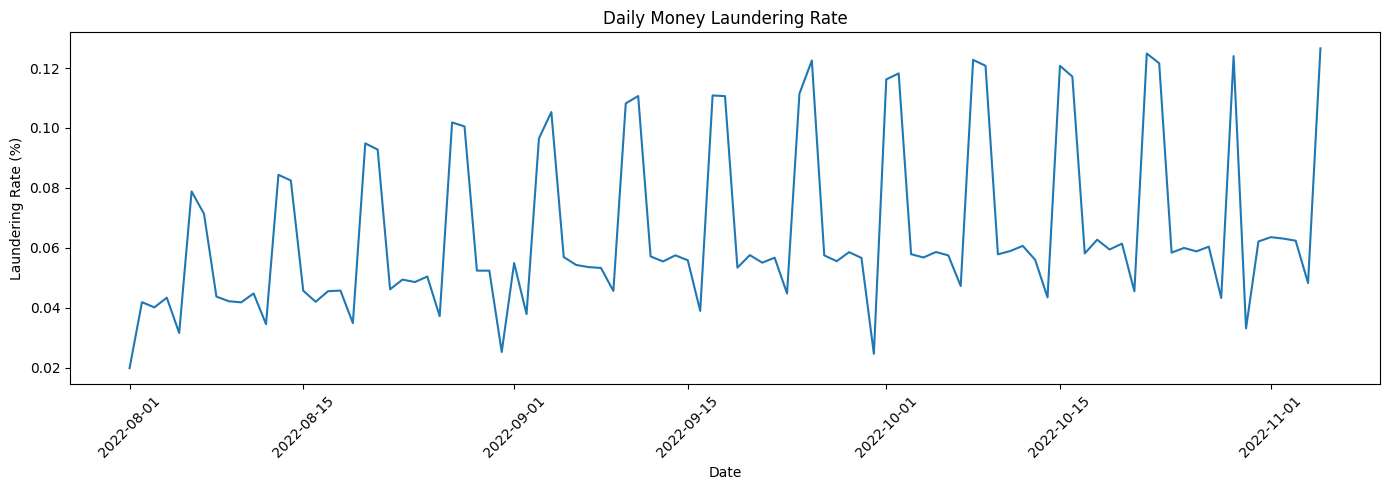

In [29]:
# Plot daily laundering rate
daily_plot = daily_analysis.toPandas()

plt.figure(figsize=(14, 5))
plt.plot(daily_plot["Date"], daily_plot["Laundering Rate (%)"])
plt.xlabel("Date")
plt.ylabel("Laundering Rate (%)")
plt.title("Daily Money Laundering Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Stop Spark

In [30]:
spark.stop()
print("Spark stopped.")

Spark stopped.
